In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [3]:
df = pd.read_csv("weather.csv")

In [4]:
df.head()
df.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun
1460,2015-12-31,0.0,5.6,-2.1,3.5,sun


In [5]:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [6]:
df_rain = df[df['weather'] == 'rain']
print(f"Rain samples: {df_rain.shape[0]}")

Rain samples: 641


In [7]:
sun_count = df[df['weather'] == 'sun'].shape[0]
print(sun_count)

640


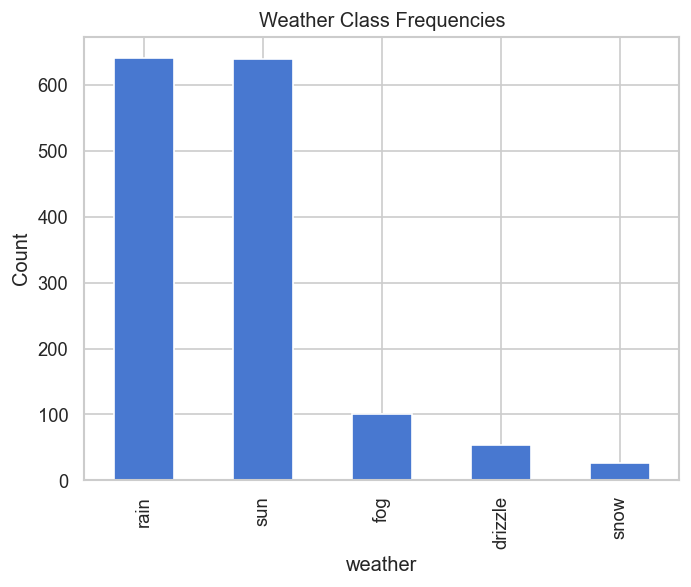

In [8]:
df_weather = df['weather'].value_counts()
df_weather.plot(kind='bar')
plt.xlabel('weather')
plt.ylabel('Count')
plt.title('Weather Class Frequencies')
plt.show()

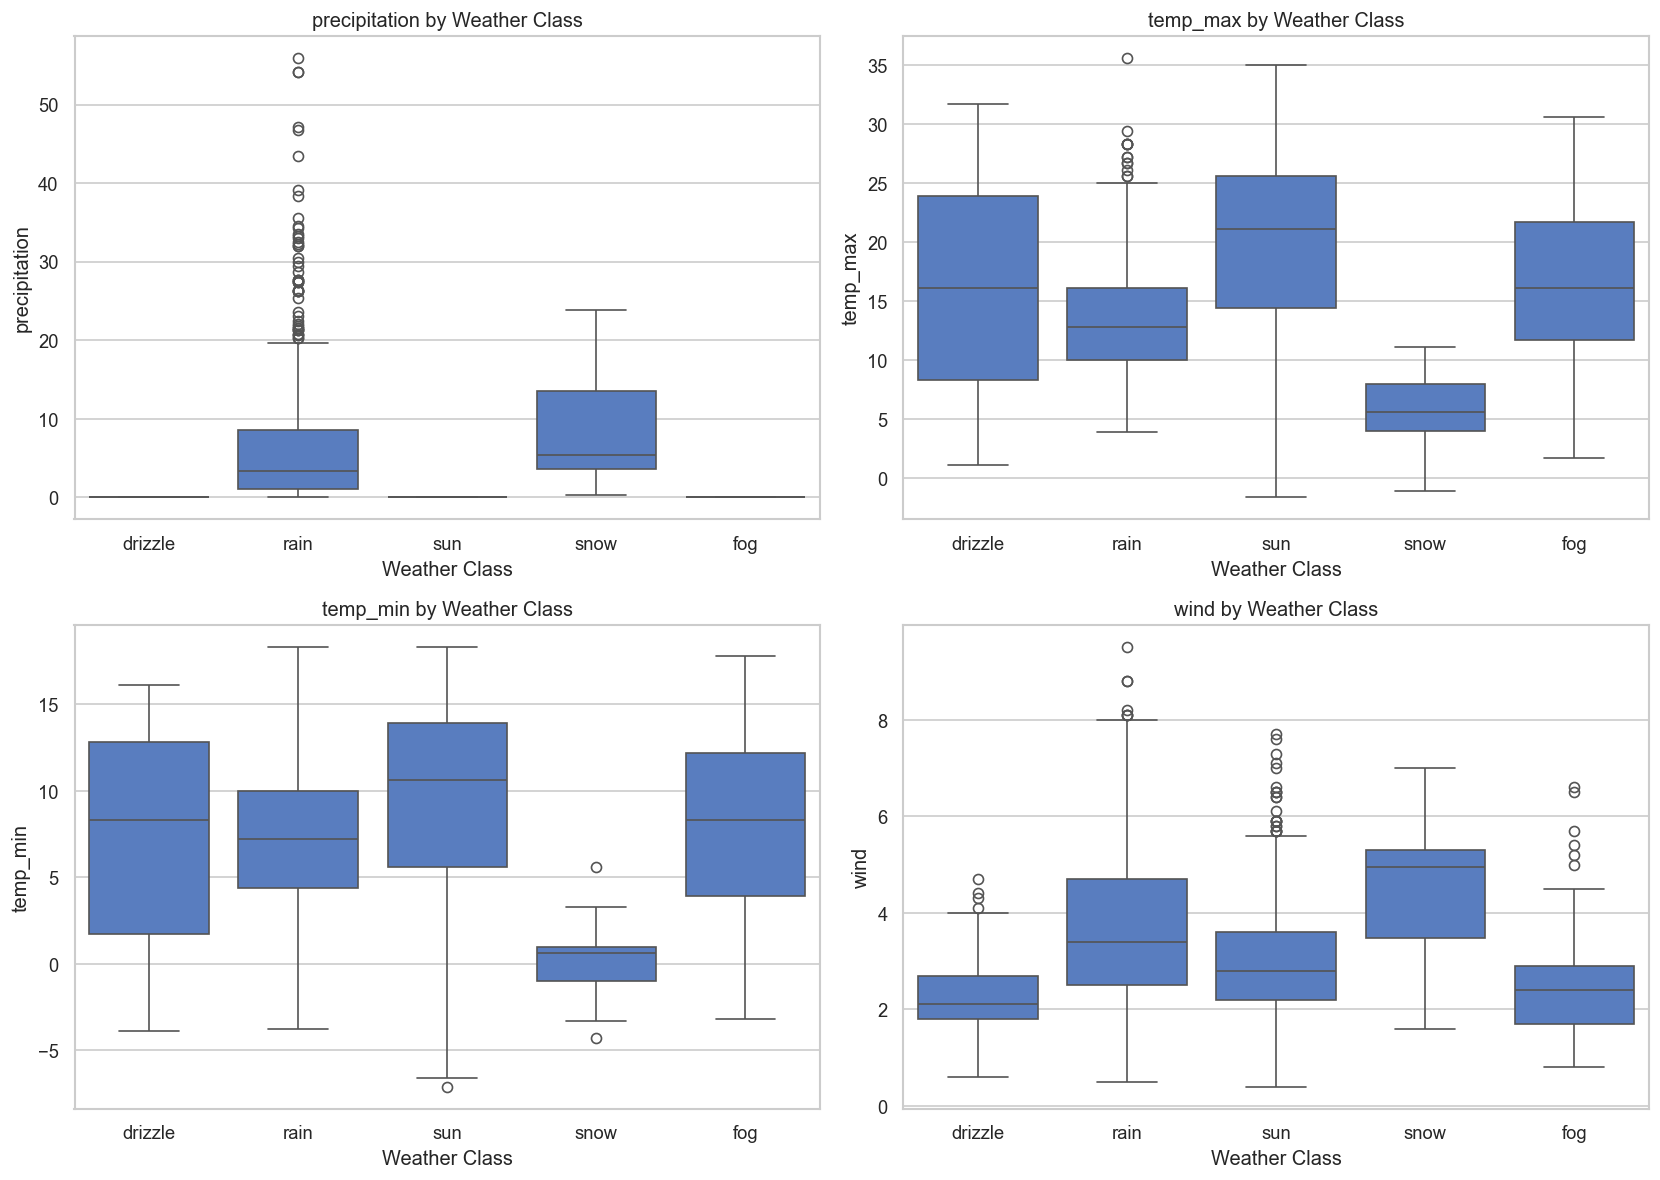

In [10]:
features = ['precipitation','temp_max','temp_min','wind']
fig,axes = plt.subplots(2,2,figsize=(14,10))
axes = axes.flatten()
for i, feature in enumerate(features):
    sns.boxplot(data=df, x='weather', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature} by Weather Class')
    axes[i].set_xlabel('Weather Class')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

# Keep only rain and sun records
df_binary = df[df['weather'].isin(['rain', 'sun'])]

# Features
X = df_binary[['precipitation', 'temp_max', 'temp_min', 'wind']]

# Target
y = df_binary['weather'].map({'rain': 0, 'sun': 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1024, 4)
(257, 4)
(1024,)
(257,)


In [25]:
print(X_train.dtypes)

precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
dtype: object


In [26]:
from sklearn import tree

clf = tree.DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

clf.fit(X_train, y_train)

print("Tree Depth:", clf.get_depth())
print("Number of Leaves:", clf.get_n_leaves())

Tree Depth: 6
Number of Leaves: 16


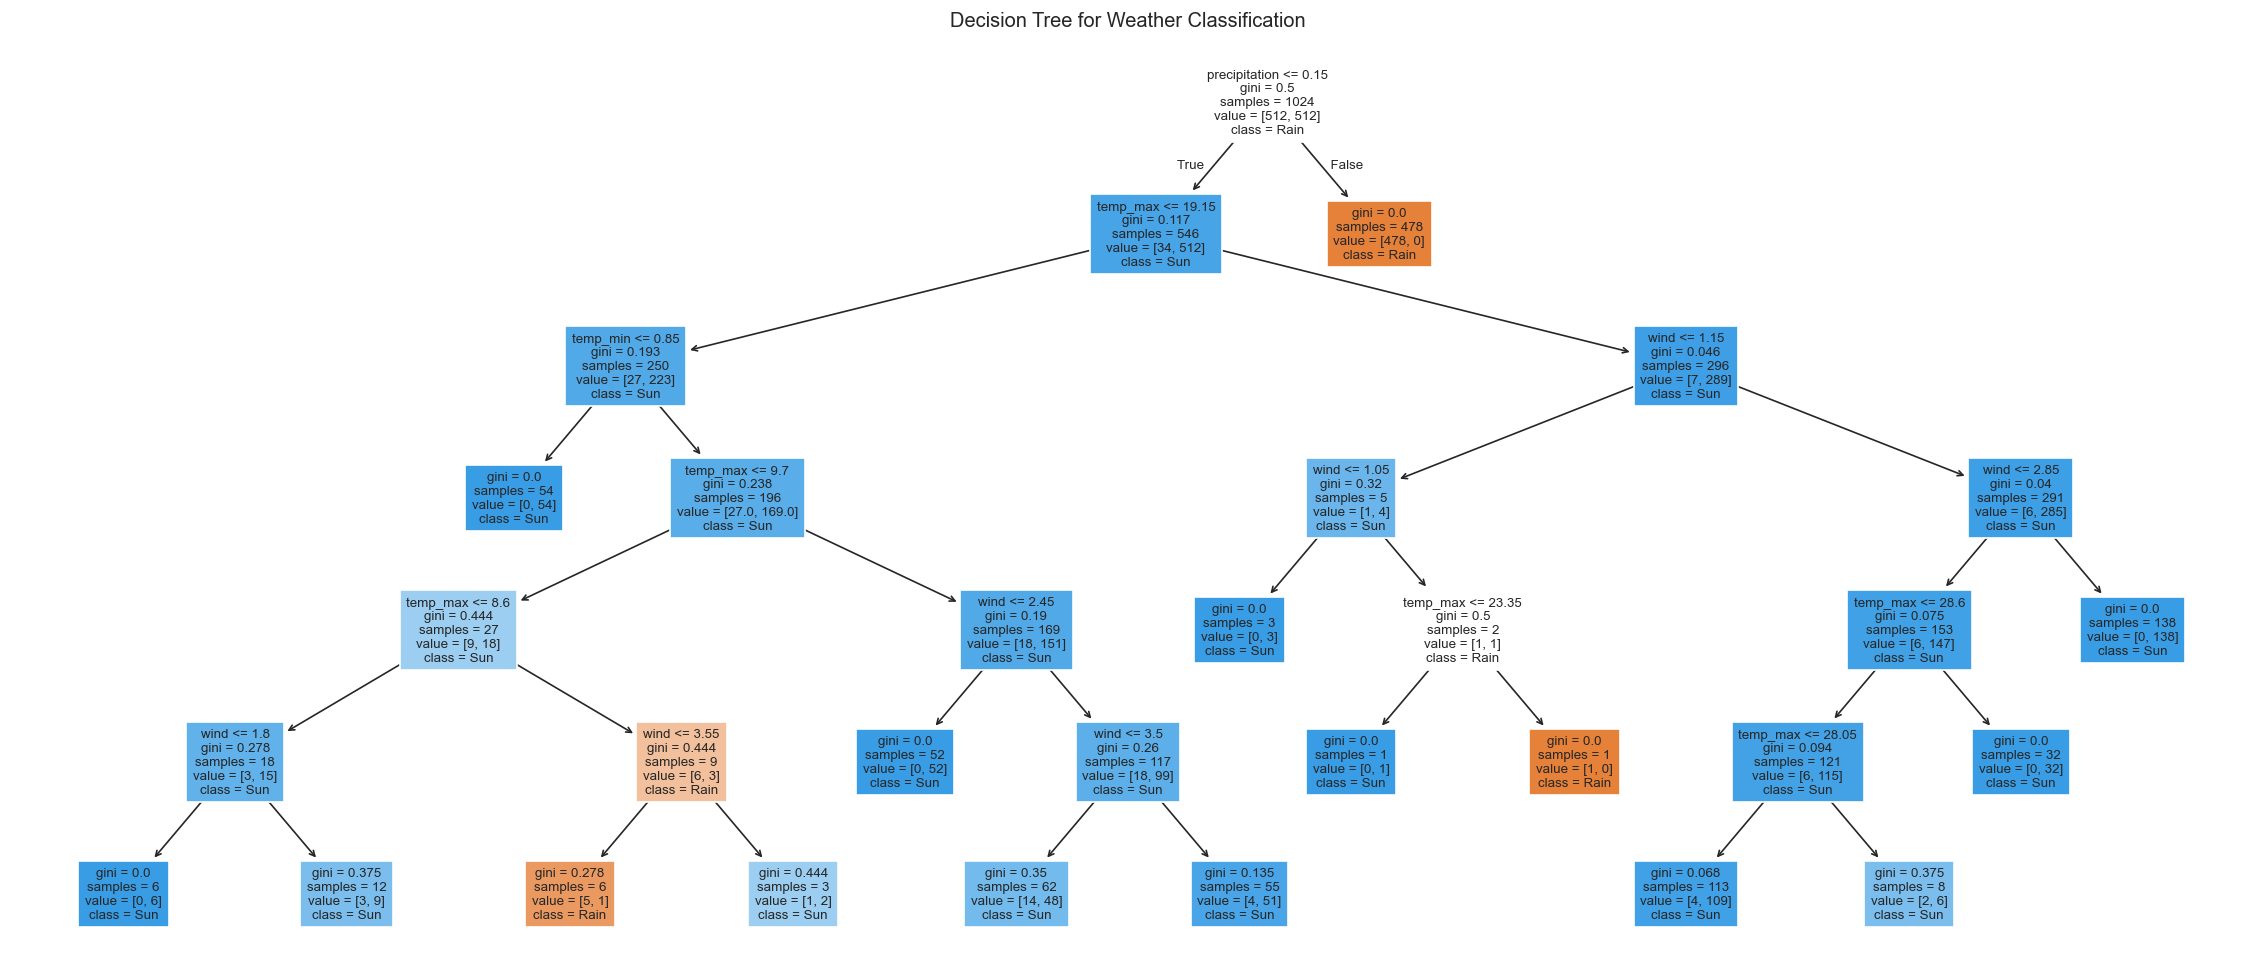

In [27]:
# Create a large figure
plt.figure(figsize=(24, 10))

# Plot the tree
tree.plot_tree(
    clf,
    filled=True,
    class_names=["Rain", "Sun"],
    feature_names=['precipitation', 'temp_max', 'temp_min', 'wind'],
    fontsize=8
)

plt.title("Decision Tree for Weather Classification")
plt.show()

Accuracy: 0.953307392996109

Classification Report:
              precision    recall  f1-score   support

        Rain       0.98      0.92      0.95       129
         Sun       0.93      0.98      0.95       128

    accuracy                           0.95       257
   macro avg       0.95      0.95      0.95       257
weighted avg       0.96      0.95      0.95       257



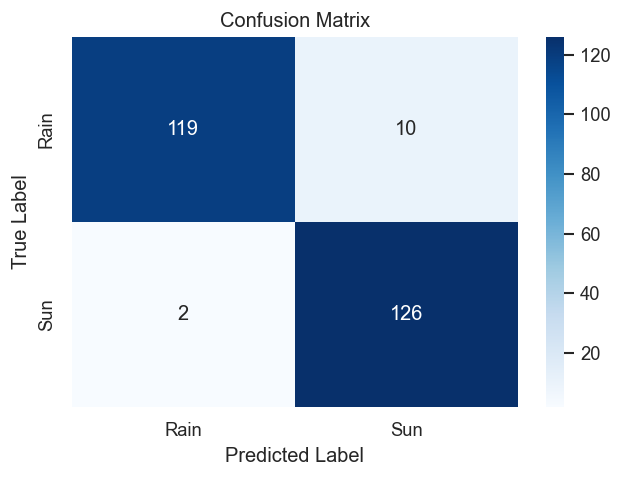

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Step 1: Predict
y_hat = clf.predict(X_test)

# Step 2: Accuracy
score = accuracy_score(y_test, y_hat)
print("Accuracy:", score)

# Step 3: Confusion matrix heatmap
cm = confusion_matrix(y_test, y_hat)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Rain", "Sun"],
    yticklabels=["Rain", "Sun"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Step 4: Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_hat,
    target_names=["Rain", "Sun"]
))

plt.show()

In [29]:
# Create test cases
case_1 = pd.DataFrame({
    'precipitation': [2],
    'temp_max': [20],
    'temp_min': [5],
    'wind': [10]
})

case_2 = pd.DataFrame({
    'precipitation': [0],
    'temp_max': [20],
    'temp_min': [5],
    'wind': [1.1]
})

# Make predictions
prediction_1 = clf.predict(case_1)
prediction_2 = clf.predict(case_2)

# Decode predictions
label_map = {0: 'rain', 1: 'sun'}

print(f"Case 1: {label_map[prediction_1[0]]}")
print(f"Case 2: {label_map[prediction_2[0]]}")

Case 1: rain
Case 2: sun


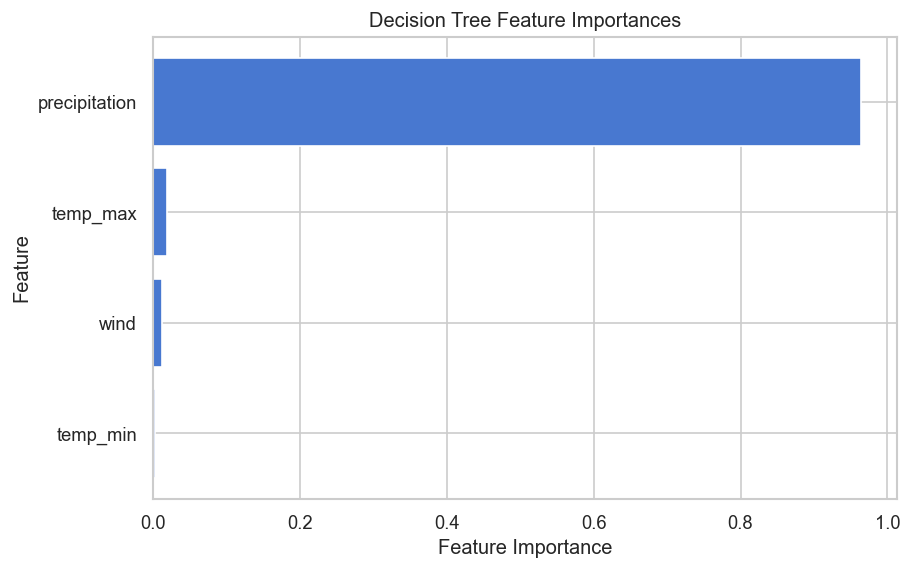

         Feature  Importance
0  precipitation    0.964593
1       temp_max    0.019662
3           wind    0.012287
2       temp_min    0.003458


In [30]:
# Get feature importances
importances = clf.feature_importances_

# Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': ['precipitation', 'temp_max', 'temp_min', 'wind'],
    'Importance': importances
})

# Sort from highest to lowest
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Plot horizontal bar chart
plt.figure(figsize=(8, 5))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Decision Tree Feature Importances')
plt.gca().invert_yaxis()  # Highest importance at top
plt.show()

# Print values
print(importance_df)